<a href="https://colab.research.google.com/github/MSIDIQ472/MUHAMMAD-SIDIQ_2411533011__ML2526/blob/main/Latihan_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
DATA_PATH = "/content/drive/MyDrive/Dataset/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

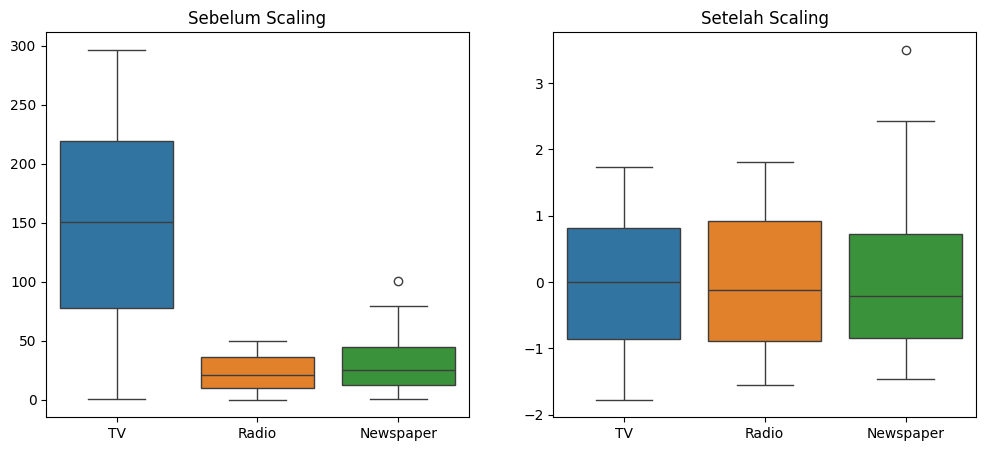

In [16]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio','Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [17]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Linear Regression")
print("RMSE Train:", rmse_train)
print("RMSE Test :", rmse_test)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234


In [18]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [40]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nLasso Regression")
print("RMSE Train:", rmse_train)
print("RMSE Test :", rmse_test)
print("Koefisien:", lasso.coef_)


Lasso Regression
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Koefisien: [4.49218143 1.42301597 0.01566227]


In [20]:
lambdas = [0.001, 0.01, 0.1, 1, 10]

ridge_train_rmse = []
ridge_test_rmse = []

lasso_train_rmse = []
lasso_test_rmse = []

for l in lambdas:
    # Ridge
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)

    ridge_train_rmse.append(
        np.sqrt(mean_squared_error(y_train, ridge.predict(X_train_scaled)))
    )
    ridge_test_rmse.append(
        np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    )

    # Lasso
    lasso = Lasso(alpha=l)
    lasso.fit(X_train_scaled, y_train)

    lasso_train_rmse.append(
        np.sqrt(mean_squared_error(y_train, lasso.predict(X_train_scaled)))
    )
    lasso_test_rmse.append(
        np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    )

In [25]:
alphas = lambdas # Define alphas using lambdas from a previous cell

gap_lr = abs(rmse_test - rmse_train)

ridge_gap_results = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)

    y_pred_train_ridge = ridge.predict(X_train_scaled)
    y_pred_test_ridge = ridge.predict(X_test_scaled)

    rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
    rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
    gap_ridge = abs(rmse_test_ridge - rmse_train_ridge)

    ridge_gap_results.append({
        "Alpha": a,
        "RMSE Train Ridge": rmse_train_ridge,
        "RMSE Test Ridge": rmse_test_ridge,
        "Gap RMSE Ridge": gap_ridge
    })

ridge_gap_df = pd.DataFrame(ridge_gap_results)

print("Gap RMSE Linear Regression")
print("RMSE Train Linear Regression:", rmse_train)
print("RMSE Test Linear Regression :", rmse_test)
print("Gap Linear Regression       :", gap_lr)

print("\nGap RMSE Ridge Regression")
display(ridge_gap_df)

ridge_gap_lebih_kecil = ridge_gap_df[ridge_gap_df["Gap RMSE Ridge"] < gap_lr]

print("\nJawaban Poin A:")

if len(ridge_gap_lebih_kecil) > 0:
    print("Ya, Ridge menurunkan gap RMSE pada beberapa nilai alpha.")
    print("Alpha yang menghasilkan gap lebih kecil dari Linear Regression:")
    display(ridge_gap_lebih_kecil)
else:
    print("Tidak, Ridge belum menurunkan gap RMSE dibandingkan Linear Regression.")

Gap RMSE Linear Regression
RMSE Train Linear Regression: 1.643031487122971
RMSE Test Linear Regression : 1.7117675228539946
Gap Linear Regression       : 0.0687360357310236

Gap RMSE Ridge Regression


,Alpha,RMSE Train Ridge,RMSE Test Ridge,Gap RMSE Ridge
0,0.001,1.635892,1.705217,0.069325
1,0.010,1.635892,1.705234,0.069342
2,0.100,1.635895,1.705412,0.069517
3,1.000,1.636162,1.707430,0.071269
4,10.000,1.659899,1.748760,0.088861



Jawaban Poin A:
Tidak, Ridge belum menurunkan gap RMSE dibandingkan Linear Regression.


In [39]:
lasso_coef_results = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    jumlah_koefisien_nol = np.sum(np.isclose(lasso.coef_, 0, atol=1e-6))

    lasso_coef_results.append({
        "Alpha": a,
        "Koefisien TV": lasso.coef_[0],
        "Koefisien Radio": lasso.coef_[1],
        "Koefisien Newspaper": lasso.coef_[2],
        "Jumlah Koefisien Nol": jumlah_koefisien_nol
    })

lasso_coef_df = pd.DataFrame(lasso_coef_results)

print("Koefisien Lasso Regression")
display(lasso_coef_df)

lasso_koefisien_nol = lasso_coef_df[lasso_coef_df["Jumlah Koefisien Nol"] > 0]

print("\nJawaban Poin B:")

if len(lasso_koefisien_nol) > 0:
    print("Ya, Lasso membuat beberapa koefisien menjadi nol pada alpha tertentu.")
    print("Alpha yang menghasilkan koefisien nol:")
    display(lasso_koefisien_nol)
else:
    print("Tidak, pada nilai alpha yang diuji Lasso belum membuat koefisien menjadi nol.")

Koefisien Lasso Regression


,Alpha,Koefisien TV,Koefisien Radio,Koefisien Newspaper,Jumlah Koefisien Nol
0,0.001,4.586252,1.489189,0.087187,0
1,0.010,4.577701,1.483172,0.080685,0
2,0.100,4.492181,1.423016,0.015662,0
3,1.000,3.638166,0.575085,0.000000,1
4,10.000,0.000000,0.000000,0.000000,3



Jawaban Poin B:
Ya, Lasso membuat beberapa koefisien menjadi nol pada alpha tertentu.
Alpha yang menghasilkan koefisien nol:


,Alpha,Koefisien TV,Koefisien Radio,Koefisien Newspaper,Jumlah Koefisien Nol
3,1.0,3.638166,0.575085,0.0,1
4,10.0,0.000000,0.000000,0.0,3


In [28]:
all_results = []

# Linear Regression tanpa regularization
all_results.append({
    "Model": "Linear Regression",
    "Alpha": 0,
    "RMSE Train": rmse_train,
    "RMSE Test": rmse_test
})

# Ridge Regression
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)

    y_pred_train_ridge = ridge.predict(X_train_scaled)
    y_pred_test_ridge = ridge.predict(X_test_scaled)

    all_results.append({
        "Model": "Ridge Regression",
        "Alpha": a,
        "RMSE Train": np.sqrt(mean_squared_error(y_train, y_pred_train_ridge)),
        "RMSE Test": np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
    })

# Lasso Regression
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    y_pred_train_lasso = lasso.predict(X_train_scaled)
    y_pred_test_lasso = lasso.predict(X_test_scaled)

    all_results.append({
        "Model": "Lasso Regression",
        "Alpha": a,
        "RMSE Train": np.sqrt(mean_squared_error(y_train, y_pred_train_lasso)),
        "RMSE Test": np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
    })

all_results_df = pd.DataFrame(all_results)

print("Semua Hasil RMSE")
display(all_results_df)

best_result = all_results_df.loc[all_results_df["RMSE Test"].idxmin()]

print("\nJawaban Poin C:")
print("RMSE test paling kecil diperoleh oleh:")
print("Model :", best_result["Model"])
print("Alpha :", best_result["Alpha"])
print("RMSE Test :", best_result["RMSE Test"])

Semua Hasil RMSE


,Model,Alpha,RMSE Train,RMSE Test
0,Linear Regression,0.000,1.643031,1.711768
1,Ridge Regression,0.001,1.635892,1.705217
2,Ridge Regression,0.010,1.635892,1.705234
3,Ridge Regression,0.100,1.635895,1.705412
4,Ridge Regression,1.000,1.636162,1.707430
5,Ridge Regression,10.000,1.659899,1.748760
6,Lasso Regression,0.001,1.635893,1.705184
7,Lasso Regression,0.010,1.635964,1.705030
8,Lasso Regression,0.100,1.643031,1.711768
9,Lasso Regression,1.000,2.140203,2.343866



Jawaban Poin C:
RMSE test paling kecil diperoleh oleh:
Model : Lasso Regression
Alpha : 0.01
RMSE Test : 1.7050297827636898


In [32]:
alpha_besar = max(alphas)

hasil_alpha_besar = all_results_df[
    (all_results_df["Alpha"] == alpha_besar) &
    (all_results_df["Model"].isin(["Ridge Regression", "Lasso Regression"]))
]

print("Hasil Model dengan Alpha Terbesar")
display(hasil_alpha_besar)

print("\n=== Pembanding Linear Regression ===")
print("RMSE Train Linear Regression:", rmse_train)
print("RMSE Test Linear Regression :", rmse_test)

print("\nJawaban Poin D:")

for index, row in hasil_alpha_besar.iterrows():
    if row["RMSE Train"] > rmse_train and row["RMSE Test"] > rmse_test:
        print(
            row["Model"],
            "dengan alpha",
            alpha_besar,
            "kemungkinan mengalami underfitting karena RMSE train dan RMSE test lebih besar dibanding Linear Regression."
        )
    else:
        print(
            row["Model"],
            "dengan alpha",
            alpha_besar,
            "belum menunjukkan underfitting yang kuat."
        )

Hasil Model dengan Alpha Terbesar


,Model,Alpha,RMSE Train,RMSE Test
5,Ridge Regression,10.0,1.659899,1.748760
10,Lasso Regression,10.0,5.176811,5.648217



=== Pembanding Linear Regression ===
RMSE Train Linear Regression: 1.643031487122971
RMSE Test Linear Regression : 1.7117675228539946

Jawaban Poin D:
Ridge Regression dengan alpha 10 kemungkinan mengalami underfitting karena RMSE train dan RMSE test lebih besar dibanding Linear Regression.
Lasso Regression dengan alpha 10 kemungkinan mengalami underfitting karena RMSE train dan RMSE test lebih besar dibanding Linear Regression.


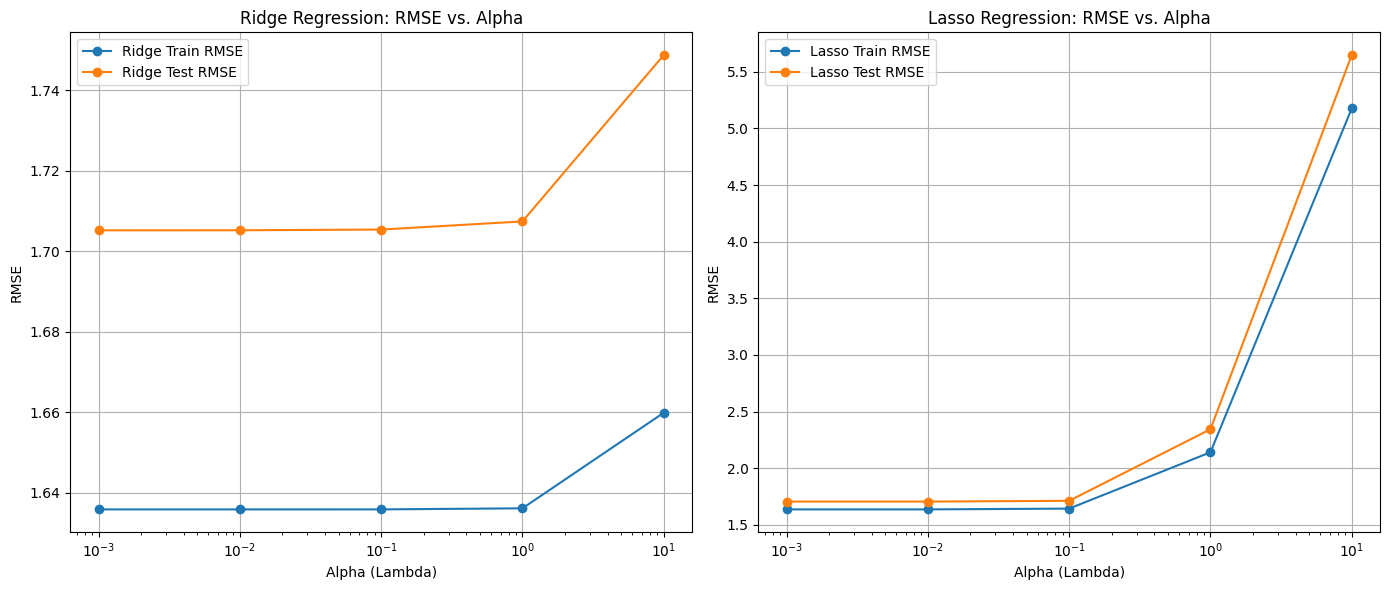

In [37]:
plt.figure(figsize=(14, 6))

# Plotting Ridge Regression RMSE
plt.subplot(1, 2, 1)
plt.plot(lambdas, ridge_train_rmse, marker='o', label='Ridge Train RMSE')
plt.plot(lambdas, ridge_test_rmse, marker='o', label='Ridge Test RMSE')
plt.xscale('log')
plt.xlabel('Alpha (Lambda)')
plt.ylabel('RMSE')
plt.title('Ridge Regression: RMSE vs. Alpha')
plt.legend()
plt.grid(True)

# Plotting Lasso Regression RMSE
plt.subplot(1, 2, 2)
plt.plot(lambdas, lasso_train_rmse, marker='o', label='Lasso Train RMSE')
plt.plot(lambdas, lasso_test_rmse, marker='o', label='Lasso Test RMSE')
plt.xscale('log')
plt.xlabel('Alpha (Lambda)')
plt.ylabel('RMSE')
plt.title('Lasso Regression: RMSE vs. Alpha')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Now, let's visualize how the coefficients of the features ('TV', 'Radio', 'Newspaper') change with varying `alpha` values for both Ridge and Lasso. This helps to see the regularization effect, especially how Lasso can drive coefficients to zero, performing feature selection.

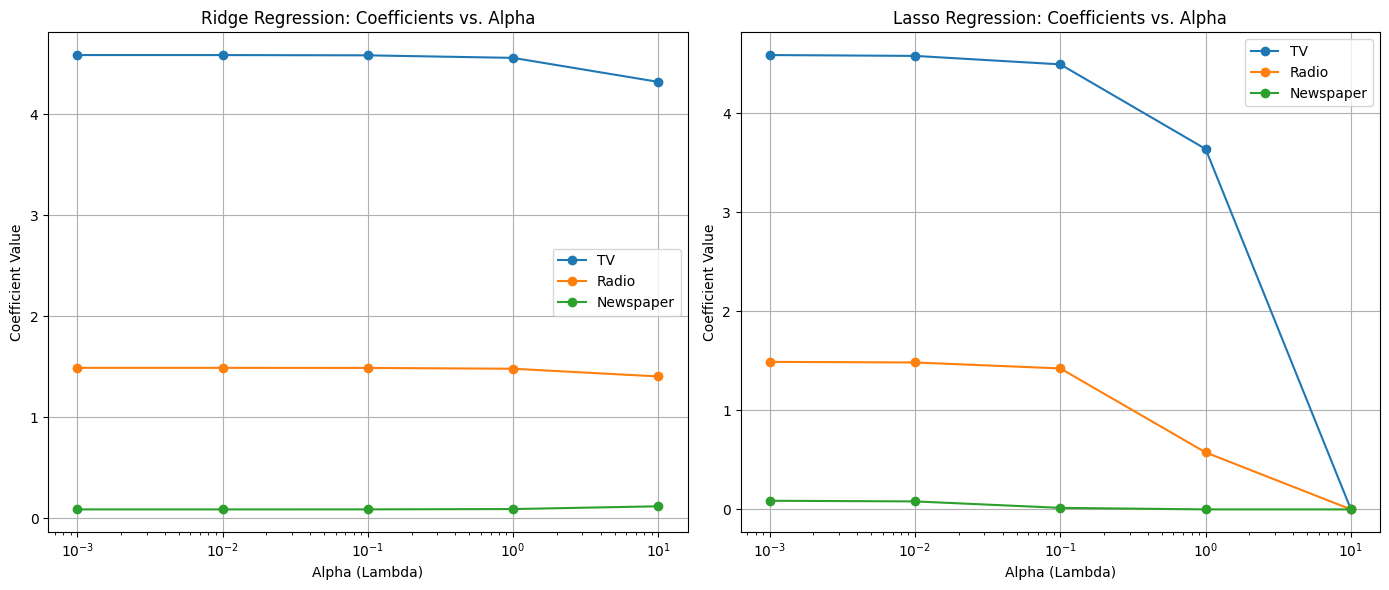

In [38]:
ridge_coefs = []
lasso_coefs = []

for l in lambdas:
    # Ridge Coefficients
    ridge_model = Ridge(alpha=l)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge_model.coef_)

    # Lasso Coefficients
    lasso_model = Lasso(alpha=l, max_iter=10000)
    lasso_model.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso_model.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

feature_names = X.columns

plt.figure(figsize=(14, 6))

# Plotting Ridge Coefficients
plt.subplot(1, 2, 1)
for i in range(len(feature_names)):
    plt.plot(lambdas, ridge_coefs[:, i], marker='o', label=feature_names[i])
plt.xscale('log')
plt.xlabel('Alpha (Lambda)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficients vs. Alpha')
plt.legend()
plt.grid(True)

# Plotting Lasso Coefficients
plt.subplot(1, 2, 2)
for i in range(len(feature_names)):
    plt.plot(lambdas, lasso_coefs[:, i], marker='o', label=feature_names[i])
plt.xscale('log')
plt.xlabel('Alpha (Lambda)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficients vs. Alpha')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [42]:
analisis_ridge_lasso = []

for a in alphas: # Changed alphas_baru to alphas
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    jumlah_nol_ridge = np.sum(np.isclose(ridge.coef_, 0, atol=1e-6))
    jumlah_nol_lasso = np.sum(np.isclose(lasso.coef_, 0, atol=1e-6))

    analisis_ridge_lasso.append({
        "Alpha": a,
        "Jumlah Koefisien Nol Ridge": jumlah_nol_ridge,
        "Jumlah Koefisien Nol Lasso": jumlah_nol_lasso
    })

analisis_ridge_lasso_df = pd.DataFrame(analisis_ridge_lasso)

print("Perbandingan Jumlah Koefisien Nol Ridge dan Lasso")
display(analisis_ridge_lasso_df)

best_alpha_baru = all_results_df.loc[all_results_df["RMSE Test"].idxmin()] # Changed hasil_alpha_baru_df to all_results_df

print("\nModel Terbaik dari Percobaan Alpha Baru")
print("Model     :", best_alpha_baru["Model"])
print("Alpha     :", best_alpha_baru["Alpha"])
print("RMSE Test :", best_alpha_baru["RMSE Test"])

print("\nKesimpulan: ")
print("Ridge Regression mengecilkan nilai koefisien ketika alpha semakin besar, tetapi tidak langsung membuat koefisien menjadi nol.")
print("Lasso Regression juga mengecilkan koefisien, tetapi dapat membuat beberapa koefisien menjadi nol pada alpha tertentu.")
print("Dalam dataset ini, fitur Newspaper cenderung lebih cepat mengecil dibanding TV dan Radio, sehingga Lasso dapat menunjukkan fitur mana yang kurang berpengaruh.")
print("Ridge lebih cocok jika semua fitur tetap ingin digunakan, sedangkan Lasso lebih cocok jika ingin melakukan seleksi fitur.")

Perbandingan Jumlah Koefisien Nol Ridge dan Lasso


,Alpha,Jumlah Koefisien Nol Ridge,Jumlah Koefisien Nol Lasso
0,0.001,0,0
1,0.010,0,0
2,0.100,0,0
3,1.000,0,1
4,10.000,0,3



Model Terbaik dari Percobaan Alpha Baru
Model     : Lasso Regression
Alpha     : 0.01
RMSE Test : 1.7050297827636898

Kesimpulan: 
Ridge Regression mengecilkan nilai koefisien ketika alpha semakin besar, tetapi tidak langsung membuat koefisien menjadi nol.
Lasso Regression juga mengecilkan koefisien, tetapi dapat membuat beberapa koefisien menjadi nol pada alpha tertentu.
Dalam dataset ini, fitur Newspaper cenderung lebih cepat mengecil dibanding TV dan Radio, sehingga Lasso dapat menunjukkan fitur mana yang kurang berpengaruh.
Ridge lebih cocok jika semua fitur tetap ingin digunakan, sedangkan Lasso lebih cocok jika ingin melakukan seleksi fitur.
